In [57]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt

In [52]:
data = pd.read_csv(
    Path.cwd() / 'misc_data' / 'industrial_sites_Industrial_Database-1.0' / 'data' / 'Industrial_Database.csv',
    sep=None,
    engine='python'
)

In [55]:
df = pd.read_csv(
    Path.cwd() / 'misc_data' / 'industrial_sites_Industrial_Database-1.0' / 'data' / 'Industrial_Database.csv',
    sep=';', index_col=0
)
df[["srid", "coordinates"]] = df.geom.str.split(";", expand=True)

In [56]:
df

,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,Emissions_ETS_2014,Emissions_EPRTR_2014,Production,Fuel_Demand,Excess_Heat_100-200C,Excess_Heat_200-500C,Excess_Heat_500C,Excess_Heat_Total,srid,coordinates
SiteID,,,,,,,,,,,,,,,,,,,
1,voestalpine AG,voestalpine Stahl Donawitz GesmbH,Kerpelystrasse 199,8700,Leoben,Austria,SRID=4326;POINT(15.067806 47.03378),Iron and steel,ETS/EPRTR,2808536.0,2810000.0,2726675.56,6346.15,192.34,173.66,0.00,366.01,SRID=4326,POINT(15.067806 47.03378)
2,voestalpine AG,voestalpine Stahl GmbH,voestalpine-Strasse 3,4020,Linz,Austria,SRID=4326;POINT(14.343056 48.281944),Iron and steel,ETS/EPRTR,8698426.0,8660000.0,8444892.86,19732.48,595.71,330.48,40.16,966.36,SRID=4326,POINT(14.343056 48.281944)
3,Schmid Industrieholding,Wopfinger Baustoffindustrie,Wopfing 156,2754,Waldegg,Austria,SRID=4326;POINT(16.085917 47.87225),Cement,ETS/EPRTR,364798.0,408000.0,477398.78,464.13,0.00,69.62,0.00,69.62,SRID=4326,POINT(16.085917 47.87225)
4,OMV Refining and Marketing GmbH,OMV Refining and Marketing GmbH,Mannswörther Strasse 28,2320,Schwechat,Austria,SRID=4326;POINT(16.493889 48.144722),Refineries,ETS/EPRTR,2713186.0,2710000.0,NaN,NaN,0.00,0.00,0.00,0.00,SRID=4326,POINT(16.493889 48.144722)
5,Zementwerk Hatschek GmbH,Zementwerk Hatschek GmbH,Hatschekstrasse 25,4810,Gmunden,Austria,SRID=4326;POINT(13.778 47.92278),Cement,ETS/EPRTR,331127.0,348000.0,607683.04,590.80,0.00,88.62,0.00,88.62,SRID=4326,POINT(13.778 47.92278)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5025,"SLOVNAFT, a.s.",Petrochémia SPC,Vlčie hrdlo 1,82412,Bratislava,Slovakia,SRID=4326;POINT(17.17326 48.129706),Chemical industry,ETS,250126.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00,SRID=4326,POINT(17.17326 48.129706)
5026,IPEĽSKÉ TEHELNE a.s.,"IPEĽSKÉ TEHELNE, a.s., závod Breznička",závod Breznička,98502,Breznička,Slovakia,NaN,Non-metallic mineral products,ETS,2805.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,NaN
5027,IPEĽSKÉ TEHELNE a.s.,"IPEĽSKÉ TEHELNE a.s., závod Lučenec",závod Lučenec - časť Fabianka,98401,Lučenec,Slovakia,SRID=4326;POINT(19.660555 48.326908),Non-metallic mineral products,ETS,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,SRID=4326,POINT(19.660555 48.326908)


In [35]:
import geopandas as gpd
from shapely import wkt

def parse_point(geom_str):
    if isinstance(geom_str, str) and geom_str.startswith('SRID=4326;POINT'):
        wkt_str = geom_str.replace('SRID=4326;', '')
        try:
            return wkt.loads(wkt_str)
        except Exception:
            return None
    else:
        return None

data['geometry'] = data['geom'].apply(parse_point)

gdf = gpd.GeoDataFrame(data, geometry='geometry', crs="EPSG:4326")

In [36]:
gdf.head()

,SiteID,CompanyName,SiteName,Address,CityCode,City,Country,geom,Subsector,DataSource,Emissions_ETS_2014,Emissions_EPRTR_2014,Production,Fuel_Demand,Excess_Heat_100-200C,Excess_Heat_200-500C,Excess_Heat_500C,Excess_Heat_Total,geometry
0,1,voestalpine AG,voestalpine Stahl Donawitz GesmbH,Kerpelystrasse 199,8700,Leoben,Austria,SRID=4326;POINT(15.067806 47.03378),Iron and steel,ETS/EPRTR,2808536.0,2810000.0,2726675.56,6346.15,192.34,173.66,0.00,366.01,POINT (15.06781 47.03378)
1,2,voestalpine AG,voestalpine Stahl GmbH,voestalpine-Strasse 3,4020,Linz,Austria,SRID=4326;POINT(14.343056 48.281944),Iron and steel,ETS/EPRTR,8698426.0,8660000.0,8444892.86,19732.48,595.71,330.48,40.16,966.36,POINT (14.34306 48.28194)
2,3,Schmid Industrieholding,Wopfinger Baustoffindustrie,Wopfing 156,2754,Waldegg,Austria,SRID=4326;POINT(16.085917 47.87225),Cement,ETS/EPRTR,364798.0,408000.0,477398.78,464.13,0.00,69.62,0.00,69.62,POINT (16.08592 47.87225)
3,4,OMV Refining and Marketing GmbH,OMV Refining and Marketing GmbH,Mannswörther Strasse 28,2320,Schwechat,Austria,SRID=4326;POINT(16.493889 48.144722),Refineries,ETS/EPRTR,2713186.0,2710000.0,NaN,NaN,0.00,0.00,0.00,0.00,POINT (16.49389 48.14472)
4,5,Zementwerk Hatschek GmbH,Zementwerk Hatschek GmbH,Hatschekstrasse 25,4810,Gmunden,Austria,SRID=4326;POINT(13.778 47.92278),Cement,ETS/EPRTR,331127.0,348000.0,607683.04,590.80,0.00,88.62,0.00,88.62,POINT (13.778 47.92278)


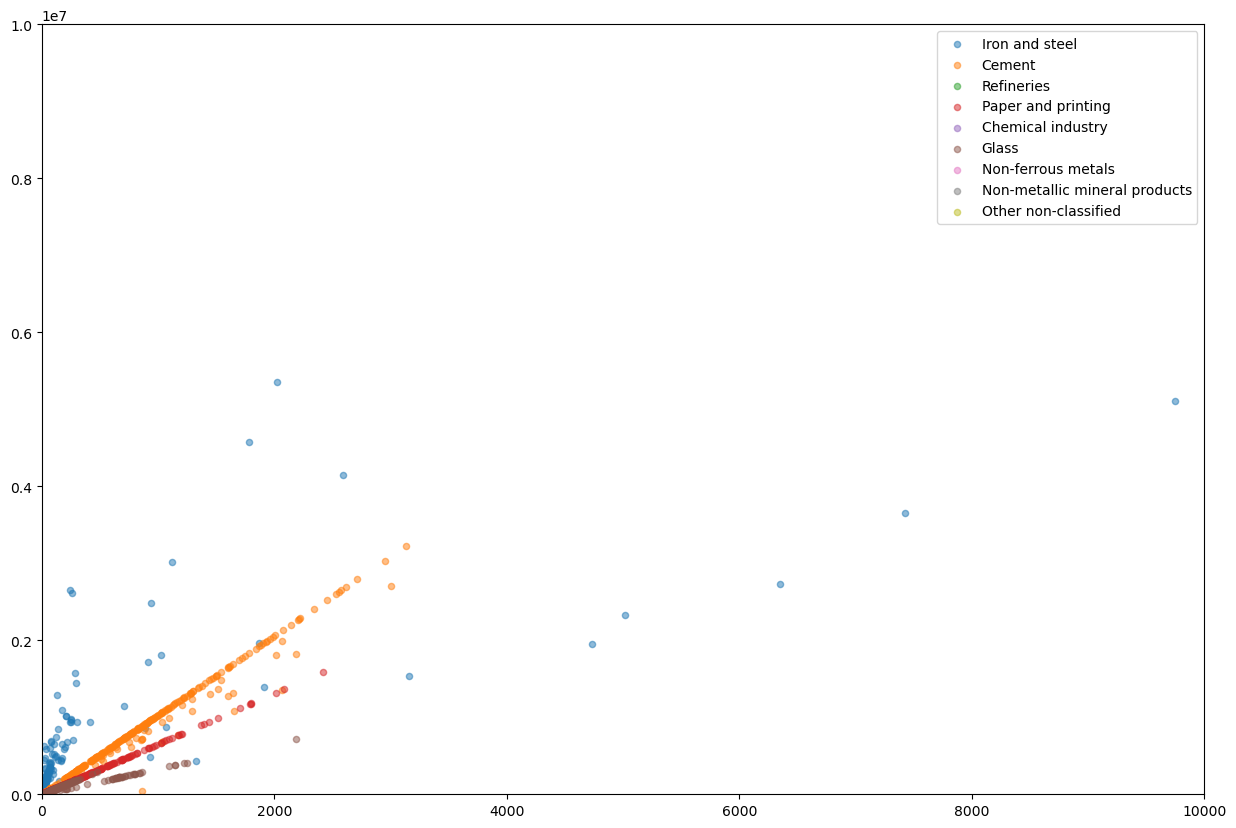

In [49]:
fig, ax = plt.subplots(figsize=(15, 10))

# Create color mapping for subsectors
subsectors = gdf['Subsector'].unique()
colors = plt.cm.tab10(range(len(subsectors)))
color_map = dict(zip(subsectors, colors))

# Map colors to each point based on subsector
point_colors = gdf['Subsector'].map(color_map)

for subsector, color in color_map.items():
    mask = gdf['Subsector'] == subsector
    ax.scatter(
        gdf.loc[mask, 'Fuel_Demand'],
        gdf.loc[mask, 'Production'],
        s=20,
        c=[color],
        label=subsector,
        alpha=0.5
    )

ax.legend(loc='upper right')

ax.set_xlim(0, 10000)
ax.set_ylim(0, 1e7)

plt.show()

In [ ]:
ratios = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industry_sector_ratios.csv', index_col=0
)

,Electric arc,DRI + Electric arc,Integrated steelworks,HVC,HVC (mechanical recycling),HVC (chemical recycling),Ammonia,Chlorine,Methanol,Other chemicals,...,"Food, beverages and tobacco",Alumina production,Aluminium - primary production,Aluminium - secondary production,Other non-ferrous metals,Transport equipment,Machinery equipment,Textiles and leather,Wood and wood products,Other industrial sectors
MWh/tMaterial,,,,,,,,,,,,,,,,,,,,,
elec,1.122141,1.444141,1.031528,2.453750,0.547,6.9,0.000,3.6000,0.000,5.070319,...,0.612683,1.392549,14.760581,1.628537,3.240152,0.228642,0.256673,0.304701,0.855880,0.241559
coal,0.000000,0.000000,0.154117,0.000000,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
coke,0.000000,0.000000,0.184750,0.000000,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
biomass,0.000000,0.000000,0.000000,0.000000,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.649137,0.000000,0.000000,0.000000,0.000000,0.065861,0.065072,0.268927,1.825742,0.070888
methane,0.166574,0.166574,0.332487,3.294687,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,3.689891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hydrogen,0.000000,1.700000,0.000000,0.172661,0.000,0.0,0.000,-0.9372,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
heat,0.004511,0.004511,0.005748,0.181899,0.000,0.0,0.000,0.0000,0.000,0.154505,...,0.028678,0.015394,0.044652,0.005198,0.013510,0.008214,0.009244,0.056121,0.055191,0.007617
naphtha,0.000000,0.000000,0.000000,12.622583,0.000,0.0,0.000,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ammonia,0.000000,0.000000,0.000000,0.000000,0.000,0.0,5.166,0.0000,0.000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: ylabel='MWh/tMaterial'>

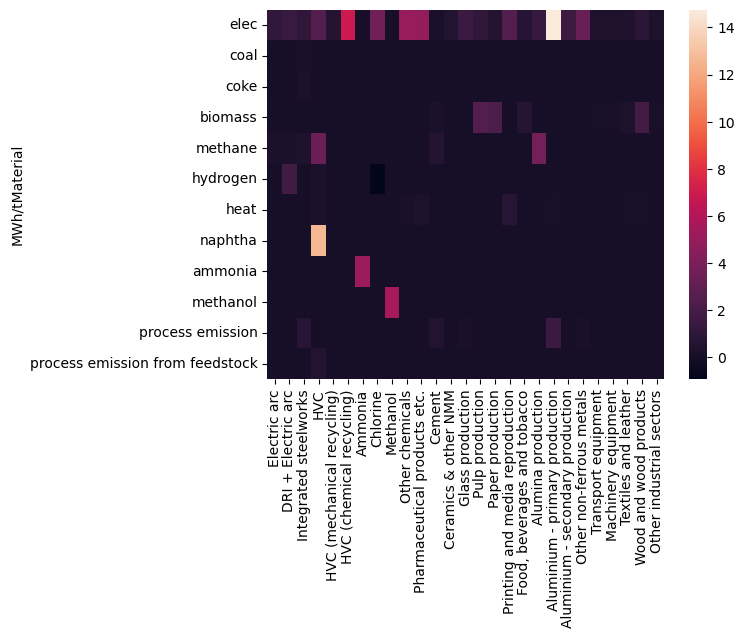

In [14]:
import seaborn as sns
sns.heatmap(ratios)

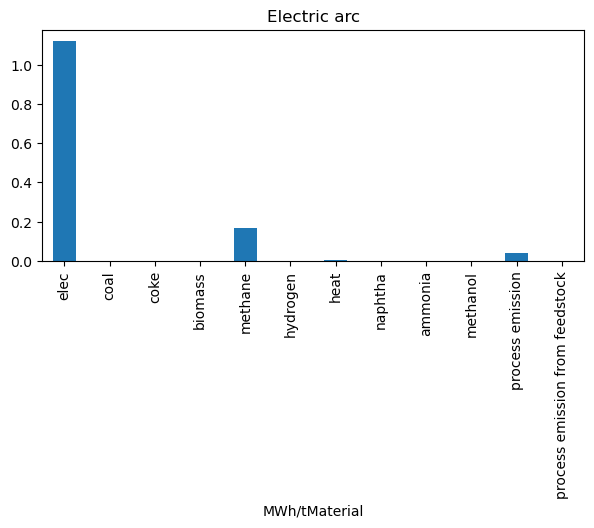

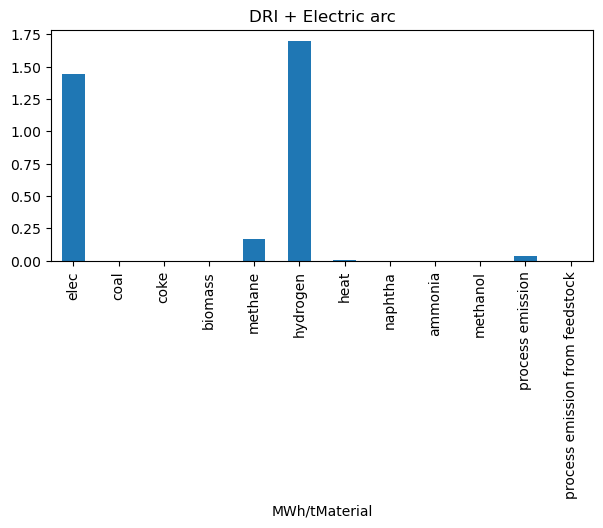

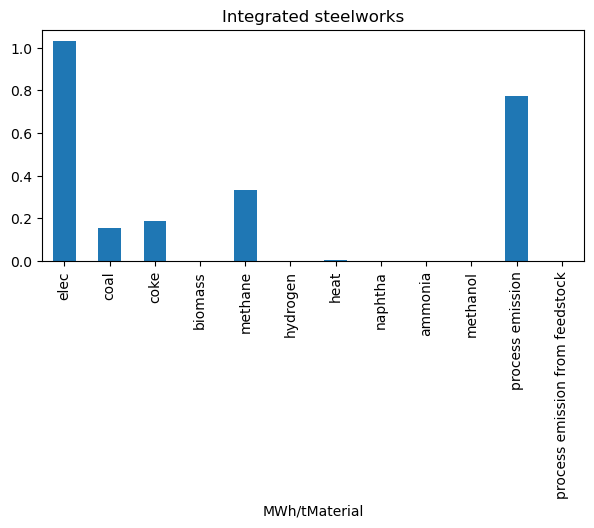

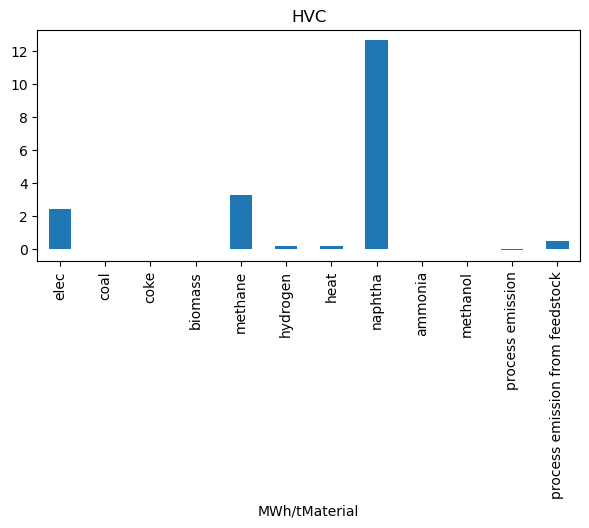

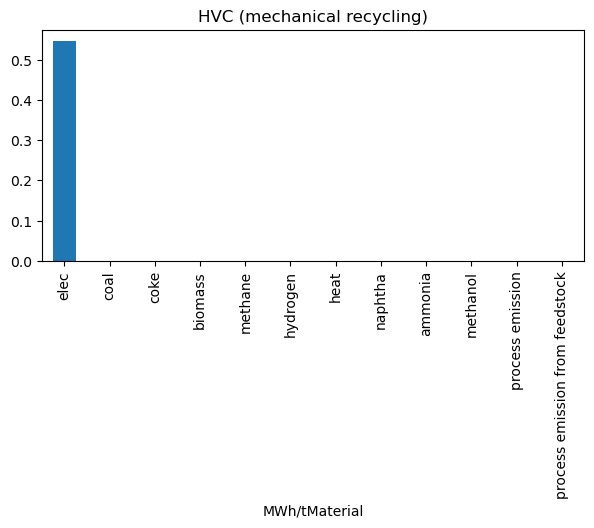

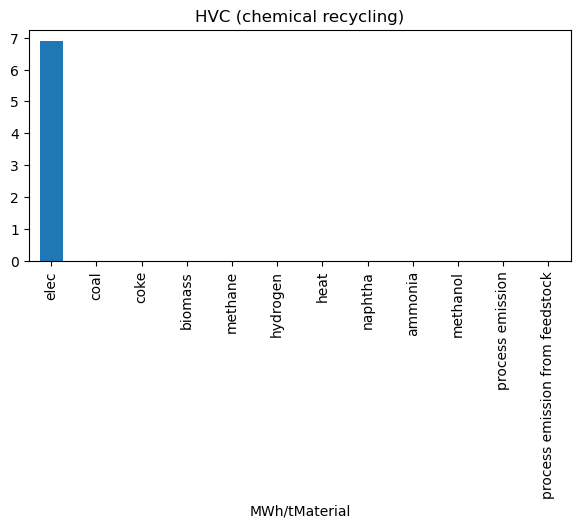

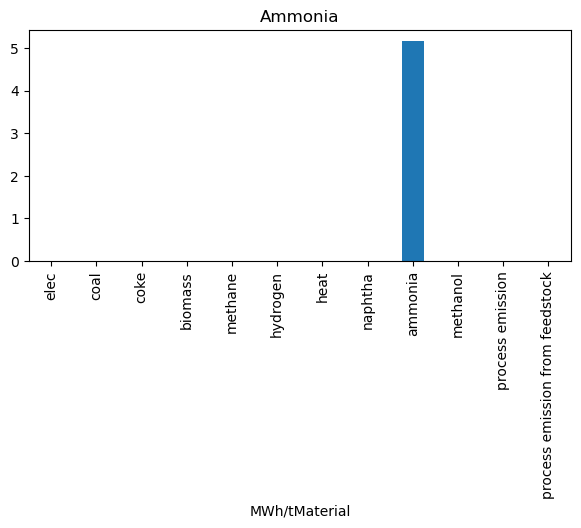

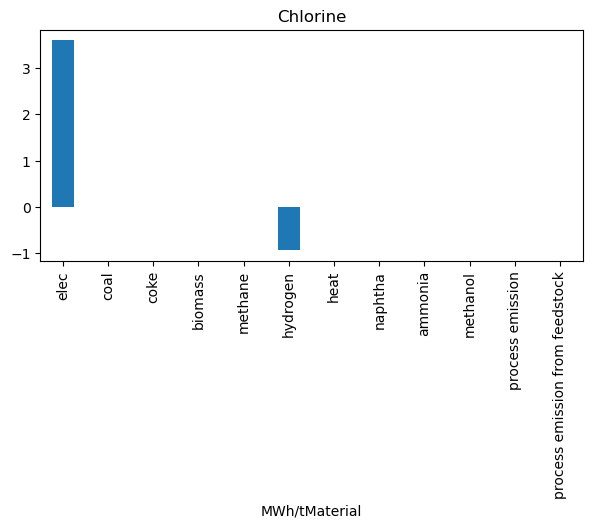

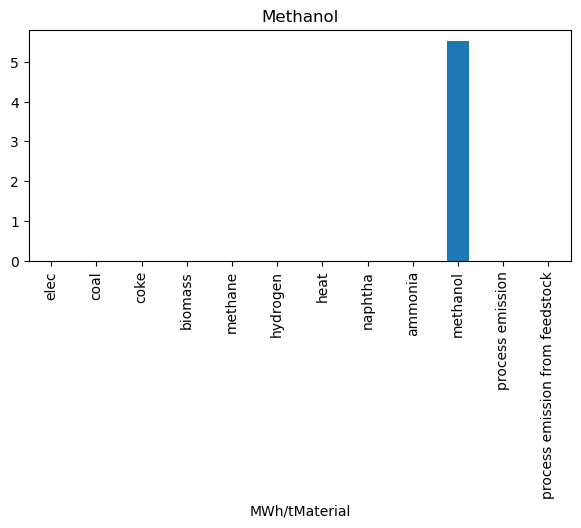

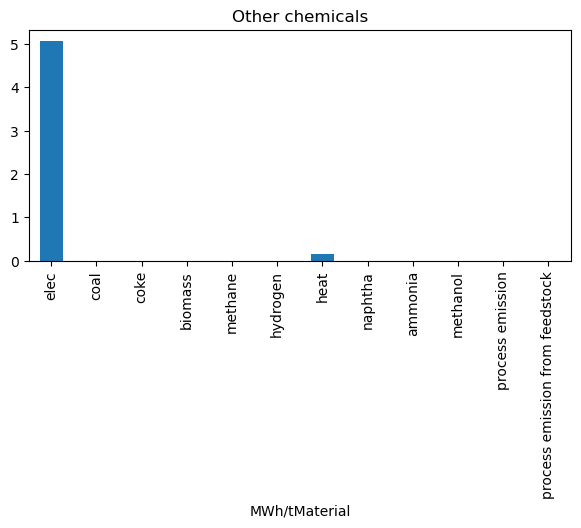

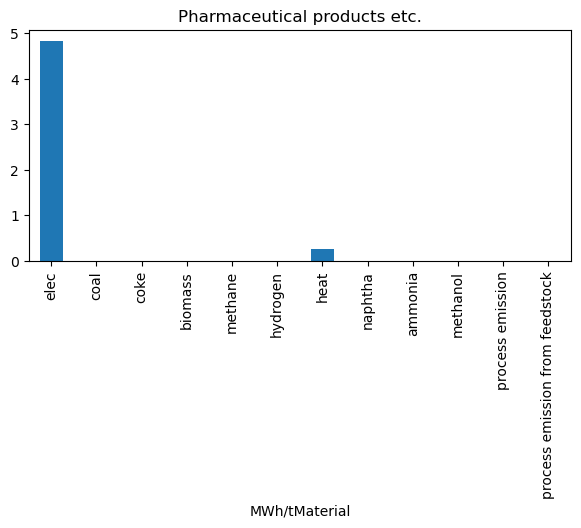

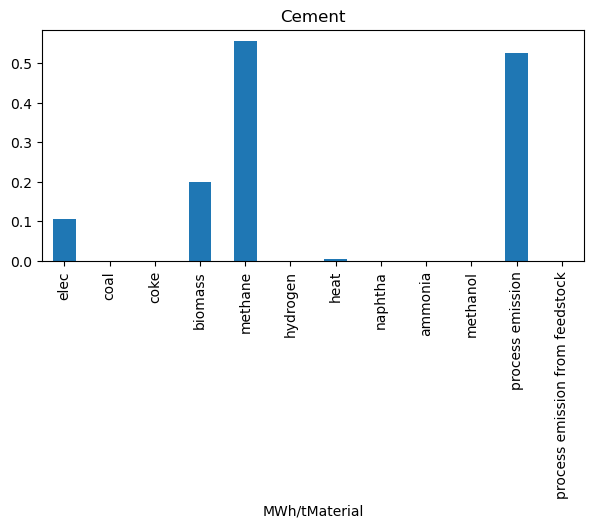

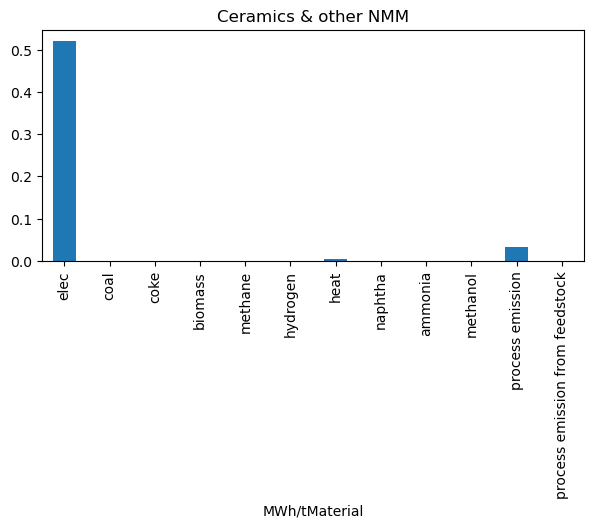

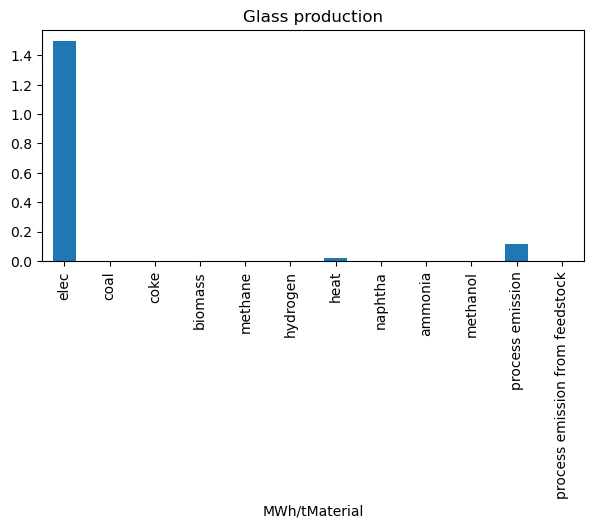

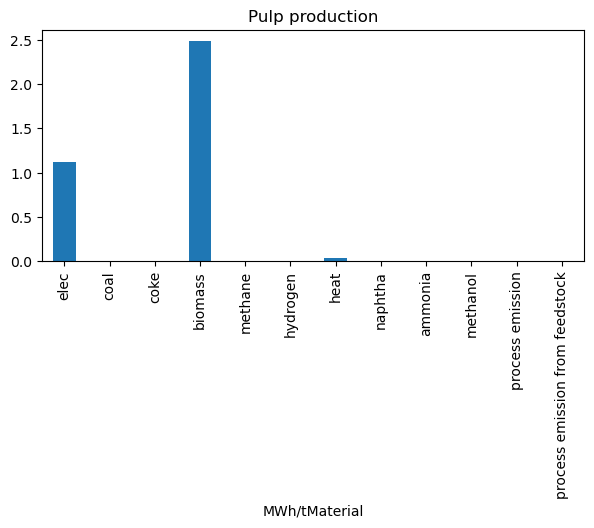

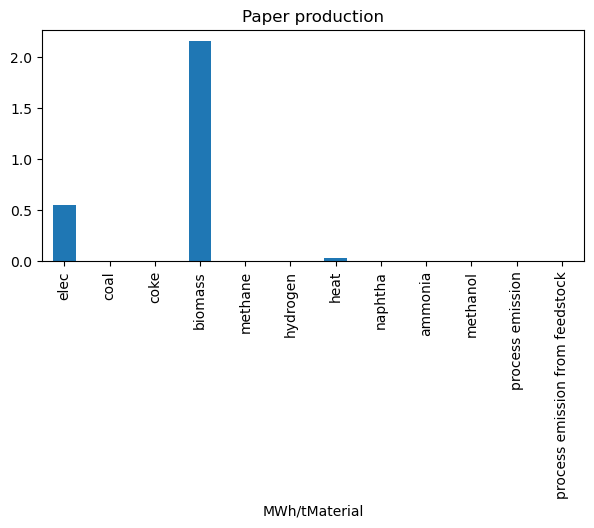

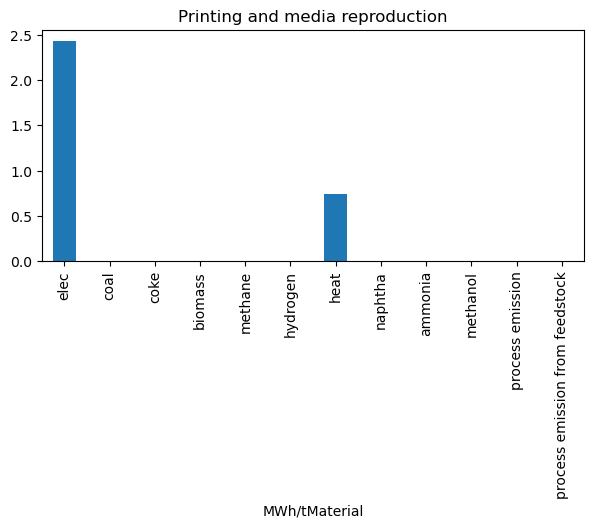

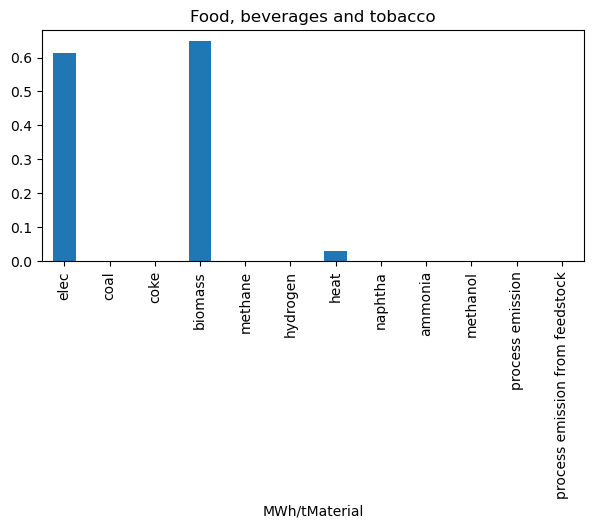

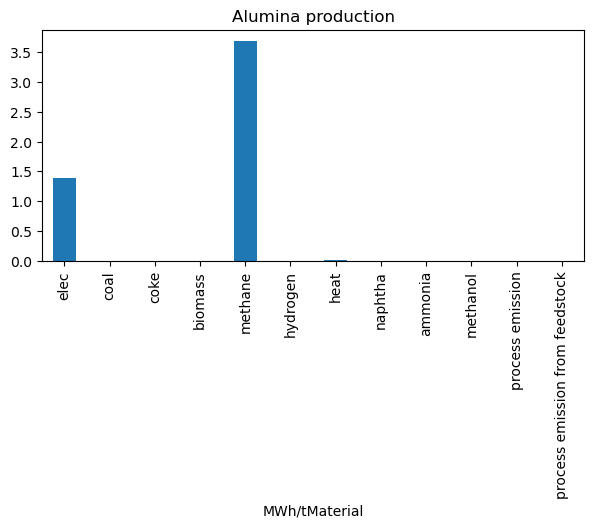

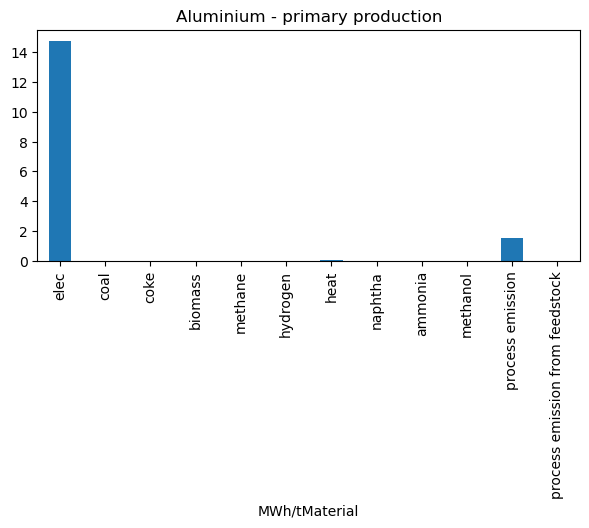

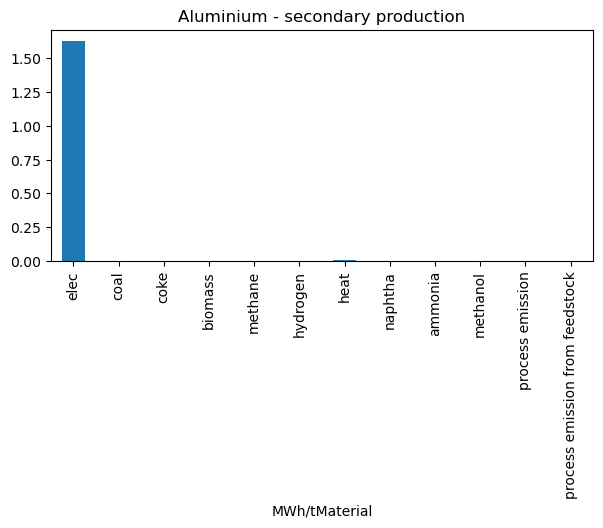

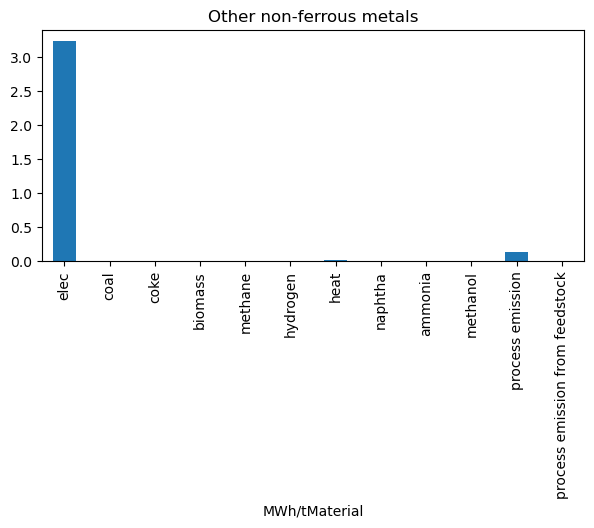

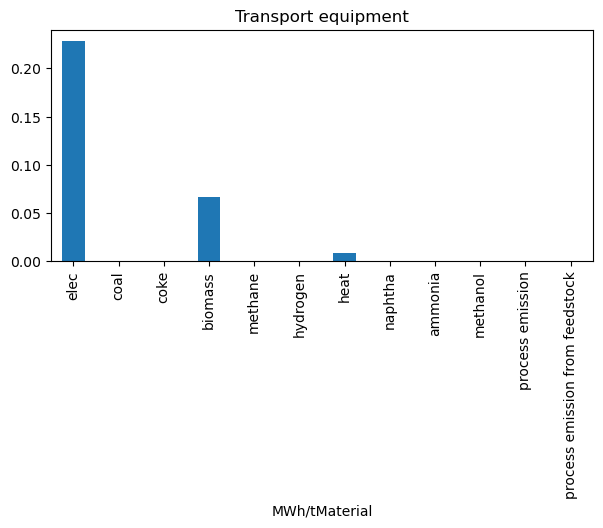

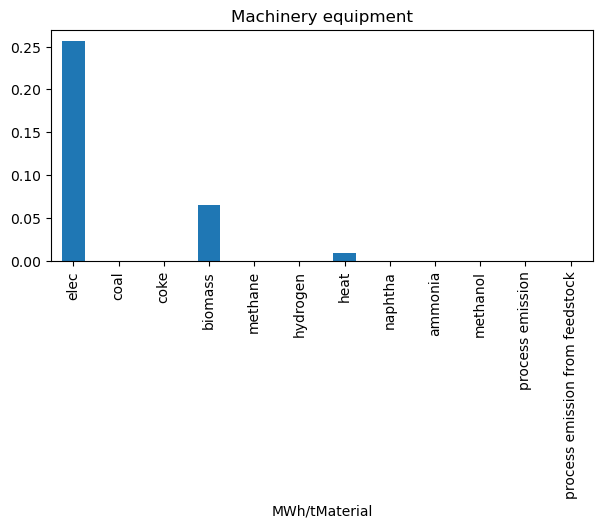

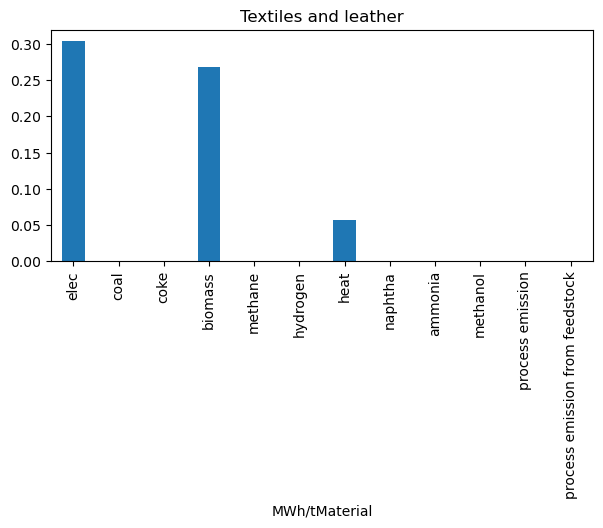

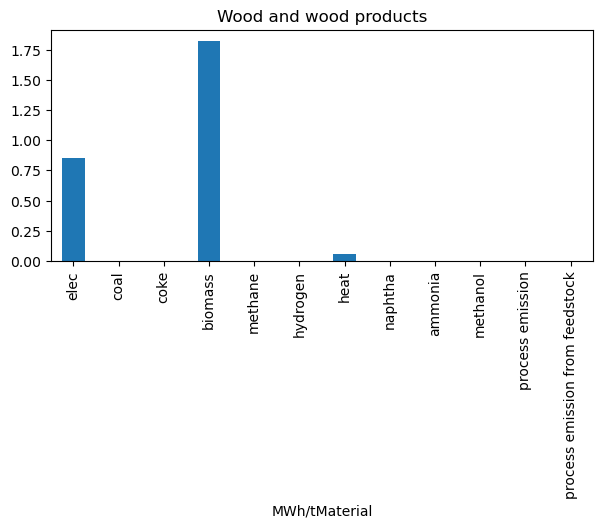

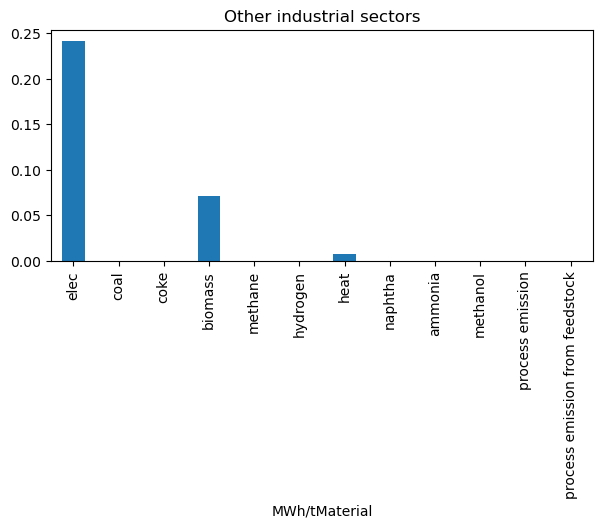

In [17]:
for col in ratios.columns:
    fig, ax = plt.subplots(figsize=(7, 3))
    ratios[col].plot.bar(ax=ax)
    ax.set_title(col)
    plt.show()


<Axes: >

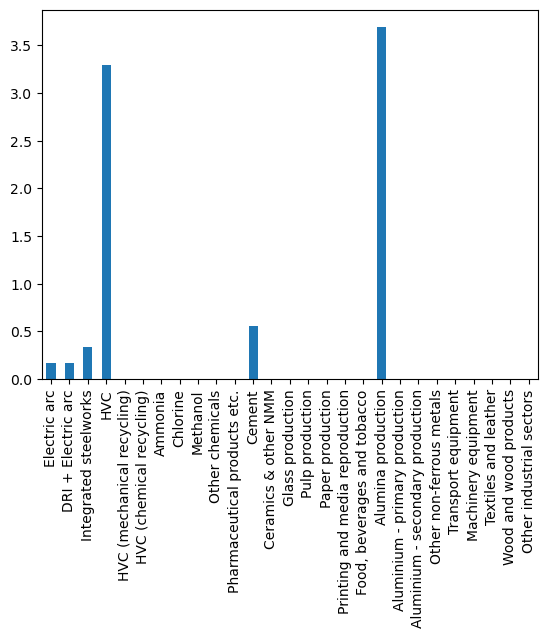

In [19]:
ratios.loc['methane'].plot.bar()

In [20]:
import pypsa

path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [21]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [ ]:
carrier = 'naphtha for industry'
buses = n.loads.bus.loc[n.loads.carrier == carrier]

n.links.loc[
    n.links.bus0.isin(buses) |
    n.links.bus1.isin(buses) |
    n.links.bus2.isin(buses) |
    n.links.bus3.isin(buses)
    ].carrier.unique()

array(['naphtha for industry'], dtype=object)

In [32]:
n.loads.loc[n.loads.carrier == carrier]

,bus,carrier,type,p_set,q_set,sign,active
Load,,,,,,,
AL0 0 naphtha for industry,AL0 0 naphtha for industry,naphtha for industry,,41.095890,0.0,-1.0,True
AT0 0 naphtha for industry,AT0 0 naphtha for industry,naphtha for industry,,1773.972603,0.0,-1.0,True
BA0 0 naphtha for industry,BA0 0 naphtha for industry,naphtha for industry,,93.607306,0.0,-1.0,True
BE0 0 naphtha for industry,BE0 0 naphtha for industry,naphtha for industry,,7801.369863,0.0,-1.0,True
BG0 0 naphtha for industry,BG0 0 naphtha for industry,naphtha for industry,,528.538813,0.0,-1.0,True
CH0 0 naphtha for industry,CH0 0 naphtha for industry,naphtha for industry,,1248.858447,0.0,-1.0,True
CZ0 0 naphtha for industry,CZ0 0 naphtha for industry,naphtha for industry,,2116.438356,0.0,-1.0,True
DE0 0 naphtha for industry,DE0 0 naphtha for industry,naphtha for industry,,3495.433790,0.0,-1.0,True
DE0 1 naphtha for industry,DE0 1 naphtha for industry,naphtha for industry,,252.283105,0.0,-1.0,True


In [59]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [82]:
industry_carriers = [
    # 'solid biomass for industry',
    'gas for industry',
    'H2 for industry',
    # 'industry methanol',
    # 'naphtha for industry',
    # 'low-temperature heat for industry',
    # 'industry electricity',
    # 'process emissions',
    # 'NH3',
    # 'coal for industry',
]

In [83]:
n.loads.loc[n.loads.carrier.isin(industry_carriers), 'p_set'].sum() * 8760 / 1e6

1166.5299999999997

In [80]:
ll = n.loads.loc[n.loads.carrier.isin(industry_carriers), ['p_set', 'carrier']]

<Axes: xlabel='carrier'>

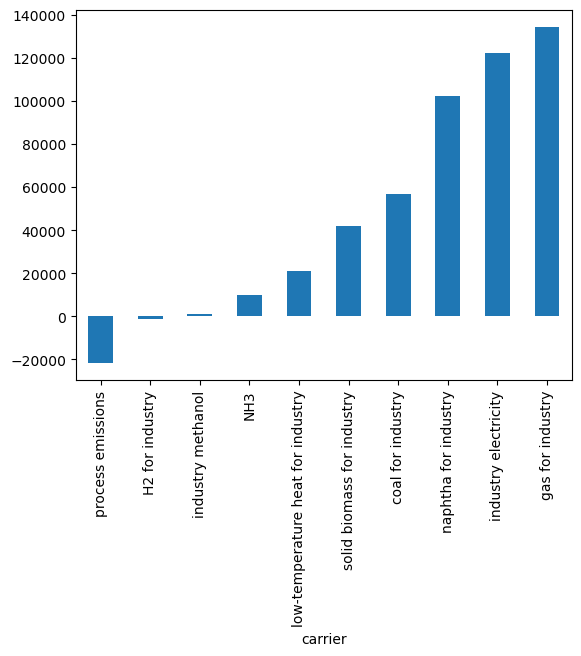

In [81]:
ll.groupby('carrier')['p_set'].sum().sort_values().plot.bar()